In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(""), '..', 'lime_ndt')))
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(""), '..')))

In [2]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from lime_ndt.lime_tabular import LimeTabularExplainer
from lime_ndt.utils.ndt_sklearn_wrapper import NDTRegressorWrapper

# Charger le dataset Digits
data = load_digits()
X = data.data
y = data.target

# Séparer en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Entraîner le modèle global Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Fonction de prédiction globale utilisant le Random Forest
def predict_fn(X):
    return rf.predict_proba(X)

# Créer l'explainer LIME-NDT
explainer = LimeTabularExplainer(
    X_train,
    feature_names=[f'pixel_{i}' for i in range(X.shape[1])],
    class_names=[str(i) for i in range(10)],
    discretize_continuous=False,
    mode='classification',
)

# Créer le modèle local NDT
model_classifier = NDTRegressorWrapper(D=X_train.shape[1])

# Expliquer une instance
exp = explainer.explain_instance(
    X_test[0],
    predict_fn,
    num_features=64,
    model_regressor=model_classifier
)

print("Explication locale (feature, poids):")
print(exp.as_list())

mean_leaf_values shape: (31, 1, 1)
self.L: 31 self.C: 1
mean_leaf_values shape after squeeze: (31, 1)



c:\Users\DELL\Desktop\lime_ndt\.venv\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 936us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Explication locale (feature, poids):
[('pixel_19', 0.3148223932243106), ('pixel_20', 0.24168757729063758), ('pixel_10', -0.17032487507948213), ('pixel_44', 0.10600568095732302), ('pixel_27', 0.08015569105582152), ('pixel_46', -0.07504504870129866), ('pixel_32', -0.06248554913294798), ('pixel_3', -0.053365384615384606), ('pixel_12', -0.04250024632159747), ('pixel_58', -0.027130537779519095), ('pixel_38', -0.025696263205957443), ('pixel_53', -0.017258806464981347), ('pixel_62', 0.008626040251601092), ('pixel_52', 0.0), ('pixel_42', 0.0), ('pixel_61', 0.0), ('pixel_34', 0.0), ('pixel_21', 0.0), ('pixel_2', 0.0), ('pixel_5', 0.0), ('pixel_33', 0.0), ('pixel_59', 0.0), ('pixel_30', 0.0), ('pixel_36', 0.0), ('pixel_26', 0.0), ('pixel_45', 0.0), ('pixel_9', 0.0), ('pixel_28', 0.0), ('pixel_41', 0.0), ('pixel_22', 0.0), ('pixel_60', 0.0), ('pixel_54', 0.0), ('pixel_11', 0.0), ('pixel_55', 0.0), ('pixel_51', 0.0), 

In [3]:
from lime.lime_tabular import LimeTabularExplainer

# Créer l'explainer LIME officiel
explainer_lime = LimeTabularExplainer(
    X_train,
    feature_names=[f'pixel_{i}' for i in range(X.shape[1])],
    class_names=[str(i) for i in range(10)],
    discretize_continuous=False,
    mode='classification',
)

# Expliquer une instance avec le modèle local Ridge par défaut de LIME
exp_ridge = explainer_lime.explain_instance(
    X_test[0],
    predict_fn,
    num_features=64
)

print("\nExplication locale avec Ridge (LIME officiel) (feature, poids):")
print(exp_ridge.as_list())


Explication locale avec Ridge (LIME officiel) (feature, poids):
[('pixel_19', 0.011161888706541206), ('pixel_10', -0.01100976505054152), ('pixel_20', 0.007452140534991793), ('pixel_27', 0.006762435517238849), ('pixel_44', 0.006306912616848679), ('pixel_38', -0.005596304726888485), ('pixel_58', -0.005564049169847282), ('pixel_46', -0.005372960147352459), ('pixel_52', 0.0052907661659725175), ('pixel_42', -0.0052862620767679235), ('pixel_62', 0.005148745109028542), ('pixel_12', 0.004511481329215587), ('pixel_30', -0.0038799340384868108), ('pixel_36', 0.0037463738533716233), ('pixel_43', 0.003570113175820803), ('pixel_34', 0.003325003987863467), ('pixel_50', -0.003212348971641623), ('pixel_59', -0.0028774696501119284), ('pixel_28', 0.0026884083920576058), ('pixel_61', 0.002443978761544905), ('pixel_21', -0.0023953271594321594), ('pixel_33', 0.002190047381297535), ('pixel_5', 0.001948338663951766), ('pixel_4', -0.0018814531852955562), ('pixel_41', -0.0018394501128369937), ('pixel_51', 0.00

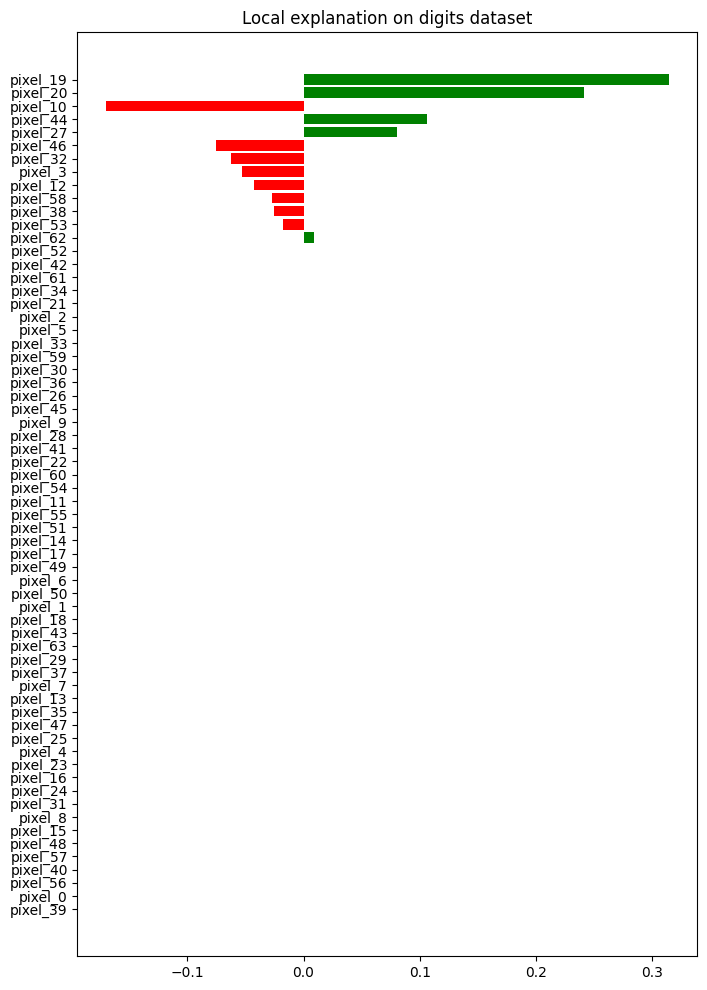

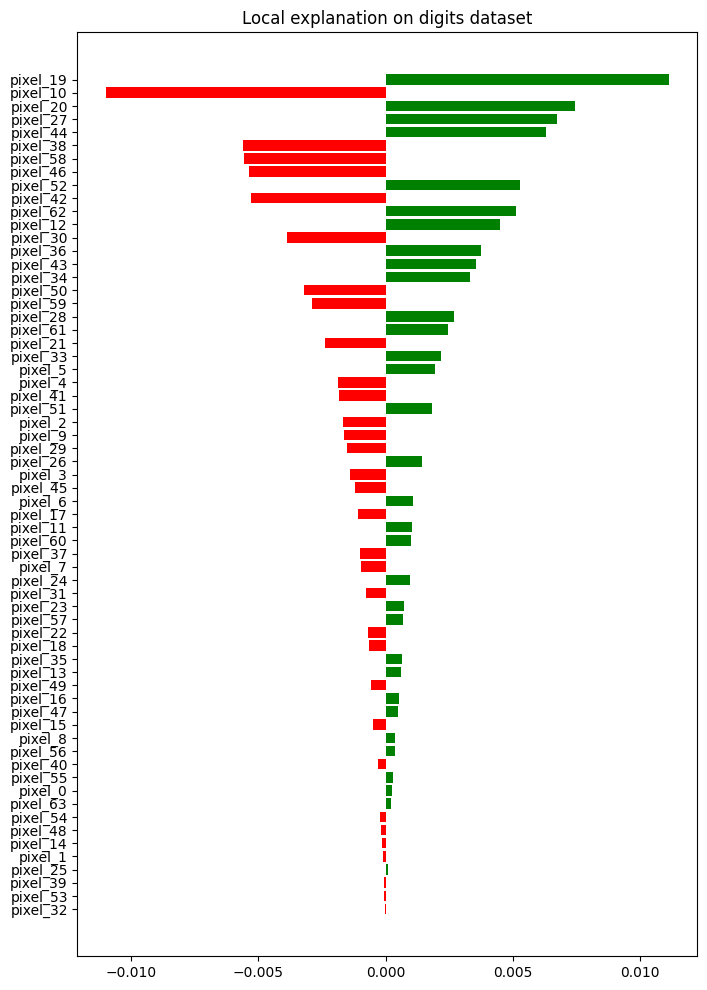

In [4]:
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 12)
fig = exp.as_pyplot_figure()
fig.set_size_inches(8, 12)
fig.axes[0].set_title("Local explanation on digits dataset")
plt.show()

fig_ridge = exp_ridge.as_pyplot_figure()
fig_ridge.set_size_inches(8, 12)
fig_ridge.axes[0].set_title("Local explanation on digits dataset")
plt.show()


Local explanation with DecisionTreeRegressor surrogate (feature, weight):
[('pixel_10', -0.10303152629628688), ('pixel_19', 0.09635572753927443), ('pixel_20', 0.061419989122873074), ('pixel_27', 0.0537012983469288), ('pixel_42', -0.03642551307011344), ('pixel_44', 0.03135550216471281), ('pixel_36', 0.02952656076264587), ('pixel_38', -0.02892951862101574), ('pixel_30', -0.028347645621692154), ('pixel_58', -0.02413966131378025), ('pixel_62', 0.024001553411189102), ('pixel_43', 0.02152315668930244), ('pixel_12', 0.015437998660123485), ('pixel_3', -0.014961122006747412), ('pixel_46', -0.014208181939021567), ('pixel_47', -0.013968354128573708), ('pixel_50', -0.012994858620120339), ('pixel_24', 0.012885687654596167), ('pixel_49', -0.012333795813510351), ('pixel_7', -0.012011019063575568), ('pixel_6', 0.011949545476136775), ('pixel_22', -0.011945064376849316), ('pixel_31', -0.01178666951414387), ('pixel_15', -0.011273246458162137), ('pixel_9', -0.011112058439091323), ('pixel_53', 0.011060145

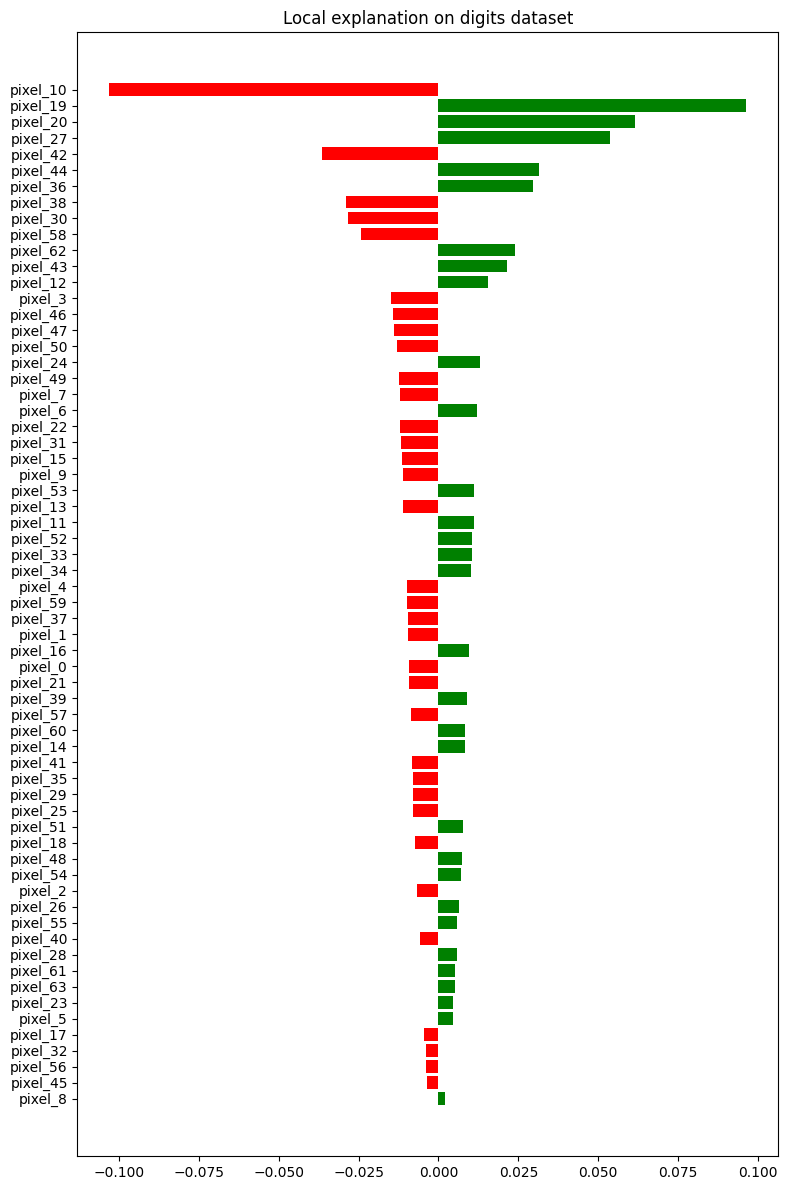

In [5]:
from sklearn.tree import DecisionTreeRegressor
import numpy as np
import matplotlib.pyplot as plt

# --- Custom wrapper class ---
class SignedDecisionTreeRegressorWrapper(DecisionTreeRegressor):
    """
    DecisionTreeRegressor wrapper for LIME that produces signed coefficients
    based on local feature–target correlations.
    """
    def fit(self, X, y, sample_weight=None):
        super().fit(X, y, sample_weight=sample_weight)
        importances = np.array(self.feature_importances_)
        
        # Compute correlation signs between X_j and y
        signs = np.zeros_like(importances)
        for j in range(X.shape[1]):
            corr = np.corrcoef(X[:, j], y)[0, 1]
            signs[j] = np.sign(corr) if not np.isnan(corr) else 0
        
        # Combine magnitude (importance) with direction (sign)
        signed_importances = importances * signs
        
        # Normalize
        if np.sum(np.abs(signed_importances)) > 0:
            signed_importances = signed_importances / np.sum(np.abs(signed_importances))
        
        self.coef_ = signed_importances
        self.intercept_ = np.array([np.mean(y)])
        return self

# --- Instantiate and use in LIME ---
local_dt = SignedDecisionTreeRegressorWrapper(max_depth=64, random_state=0)

exp_dt = explainer.explain_instance(
    X_test[0],
    predict_fn,
    num_features=64,
    model_regressor=local_dt
)

print("\nLocal explanation with DecisionTreeRegressor surrogate (feature, weight):")
print(exp_dt.as_list())

plt.rcParams['figure.figsize'] = (8, 12)
fig_dt = exp_dt.as_pyplot_figure()
fig_dt.set_size_inches(8, 12)
fig_dt.axes[0].set_title("Local explanation on digits dataset")
plt.tight_layout()
plt.show()
